# 01. scRNA Reference Processing

This notebook keeps the core scRNA workflow only (load -> QC -> normalization -> T/Myeloid programs -> sample summaries).


## Goal

Create clean reference-level immune program signals that are easier to inspect and compare across samples.


In [1]:
import os
from pathlib import Path

# Run notebooks from either the project root or the notebooks subfolder.
needed = [
    "GSE149614_HCC.scRNAseq.S71915.count.txt",
    "GSE149614_HCC.metadata.updated.txt",
]
if not all(Path(p).exists() for p in needed) and all(Path("..", p).exists() for p in needed):
    os.chdir("..")

print("Working directory:", Path.cwd())


Working directory: /Users/prateek/Downloads/Spatial HCC


In [2]:
import pandas as pd
import scanpy as sc

adata = sc.read_text(
    "GSE149614_HCC.scRNAseq.S71915.count.txt",
    delimiter="\t",
    first_column_names=True
)

print(adata)

AnnData object with n_obs × n_vars = 25712 × 71915


In [3]:
adata = adata.T
print(adata)

AnnData object with n_obs × n_vars = 71915 × 25712


In [4]:
from scipy import sparse

adata.X = sparse.csr_matrix(adata.X)
adata.layers["counts"] = adata.X.copy()

In [5]:
meta = pd.read_csv(
    "GSE149614_HCC.metadata.updated.txt",
    sep="\t"
)

print(meta.head())

                      Cell  sample  res.3   site patient stage virus celltype
0  HCC01T_AAACCTGAGGGCATGT  HCC01T     13  Tumor   HCC01     I   HBV     T/NK
1  HCC01T_AAACCTGAGTCGCCGT  HCC01T     16  Tumor   HCC01     I   HBV  Myeloid
2  HCC01T_AAACCTGCATTACCTT  HCC01T     25  Tumor   HCC01     I   HBV     T/NK
3  HCC01T_AAACCTGGTCACACGC  HCC01T      2  Tumor   HCC01     I   HBV     T/NK
4  HCC01T_AAACCTGTCCAGTATG  HCC01T      2  Tumor   HCC01     I   HBV     T/NK


In [6]:
# Set barcode column as index
meta = meta.set_index("Cell")

# Ensure order matches adata
meta = meta.loc[adata.obs_names]

# Attach metadata
adata.obs = meta

print(adata.obs.head())

                         sample  res.3   site patient stage virus celltype
HCC01T_AAACCTGAGGGCATGT  HCC01T     13  Tumor   HCC01     I   HBV     T/NK
HCC01T_AAACCTGAGTCGCCGT  HCC01T     16  Tumor   HCC01     I   HBV  Myeloid
HCC01T_AAACCTGCATTACCTT  HCC01T     25  Tumor   HCC01     I   HBV     T/NK
HCC01T_AAACCTGGTCACACGC  HCC01T      2  Tumor   HCC01     I   HBV     T/NK
HCC01T_AAACCTGTCCAGTATG  HCC01T      2  Tumor   HCC01     I   HBV     T/NK


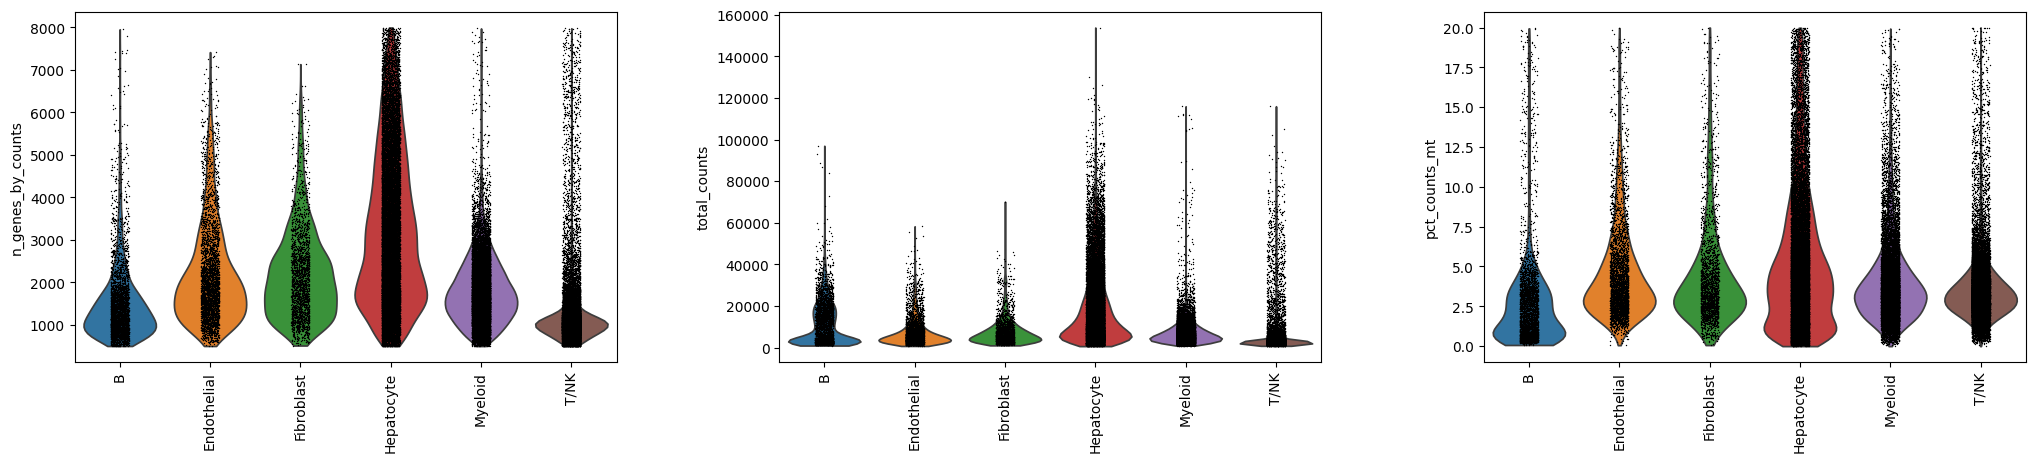

In [7]:
import scanpy as sc
import numpy as np

# Mito genes
adata.var["mt"] = adata.var_names.str.startswith("MT-")

sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True)

sc.pl.violin(adata, ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
             groupby="celltype", rotation=90)

In [8]:
adata.raw = adata  # store raw

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# Keep an unscaled log-normalized copy for cell-type specific analyses
adata_log = adata.copy()


In [9]:
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=3000,
    flavor="seurat_v3"
)

adata = adata[:, adata.var.highly_variable].copy()


/var/folders/d3/flzyycm51ddb3vbl4r5q6m740000gn/T/ipykernel_87175/601915169.py:1: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  sc.pp.highly_variable_genes(


In [10]:
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, svd_solver="arpack")

sc.pp.neighbors(adata, n_neighbors=15, n_pcs=30)
sc.tl.umap(adata)

sc.tl.leiden(adata, resolution=0.2, flavor="igraph", n_iterations=2, directed=False)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/functools.py:982: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


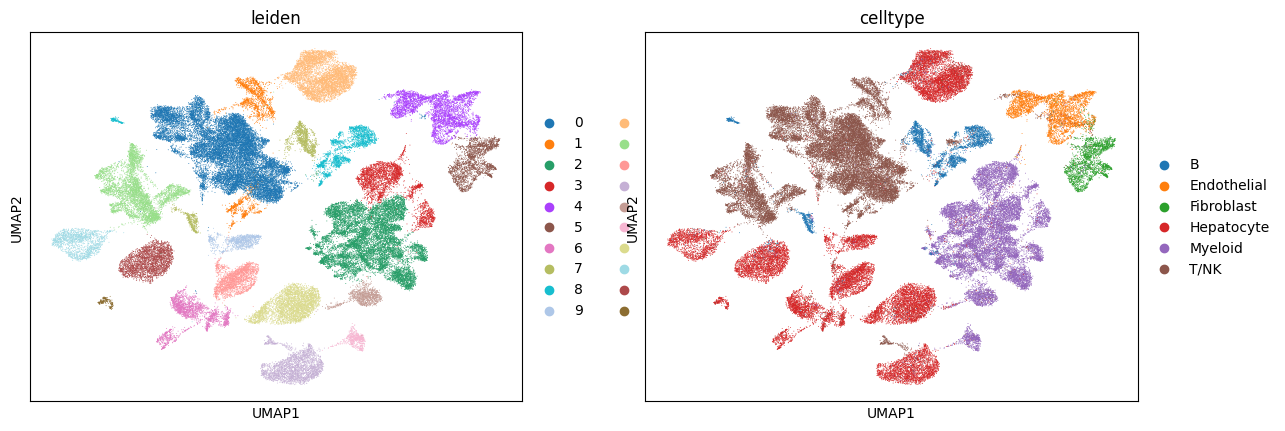

In [11]:
sc.pl.umap(adata, color=["leiden", "celltype"])

In [12]:
adata_t = adata_log[adata_log.obs["celltype"] == "T/NK"].copy()


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/functools.py:982: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
/var/folders/d3/flzyycm51ddb3vbl4r5q6m740000gn/T/ipykernel_87175/559903439.py:15: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata_t, resolution=0.8)


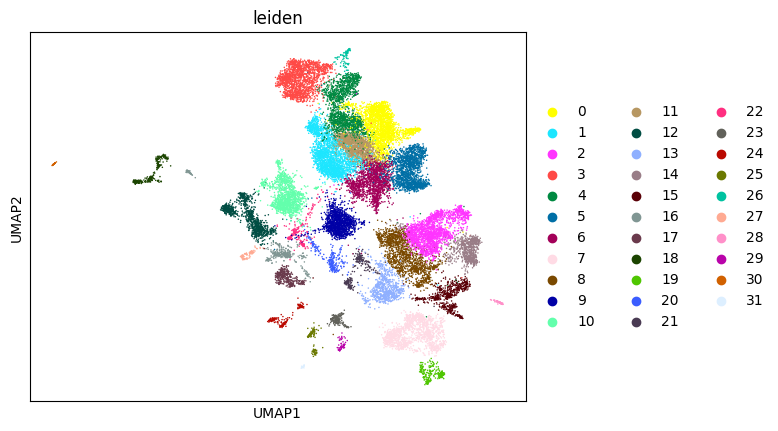

In [13]:
sc.pp.highly_variable_genes(adata_t, n_top_genes=2000)
adata_t = adata_t[:, adata_t.var.highly_variable].copy()

sc.pp.scale(adata_t, max_value=10)

# Guard against non-finite values before PCA
if sparse.issparse(adata_t.X):
    adata_t.X.data = np.nan_to_num(adata_t.X.data, nan=0.0, posinf=0.0, neginf=0.0)
else:
    adata_t.X = np.nan_to_num(adata_t.X, nan=0.0, posinf=0.0, neginf=0.0)

sc.tl.pca(adata_t)
sc.pp.neighbors(adata_t)
sc.tl.umap(adata_t)
sc.tl.leiden(adata_t, resolution=0.8)

sc.pl.umap(adata_t, color="leiden")


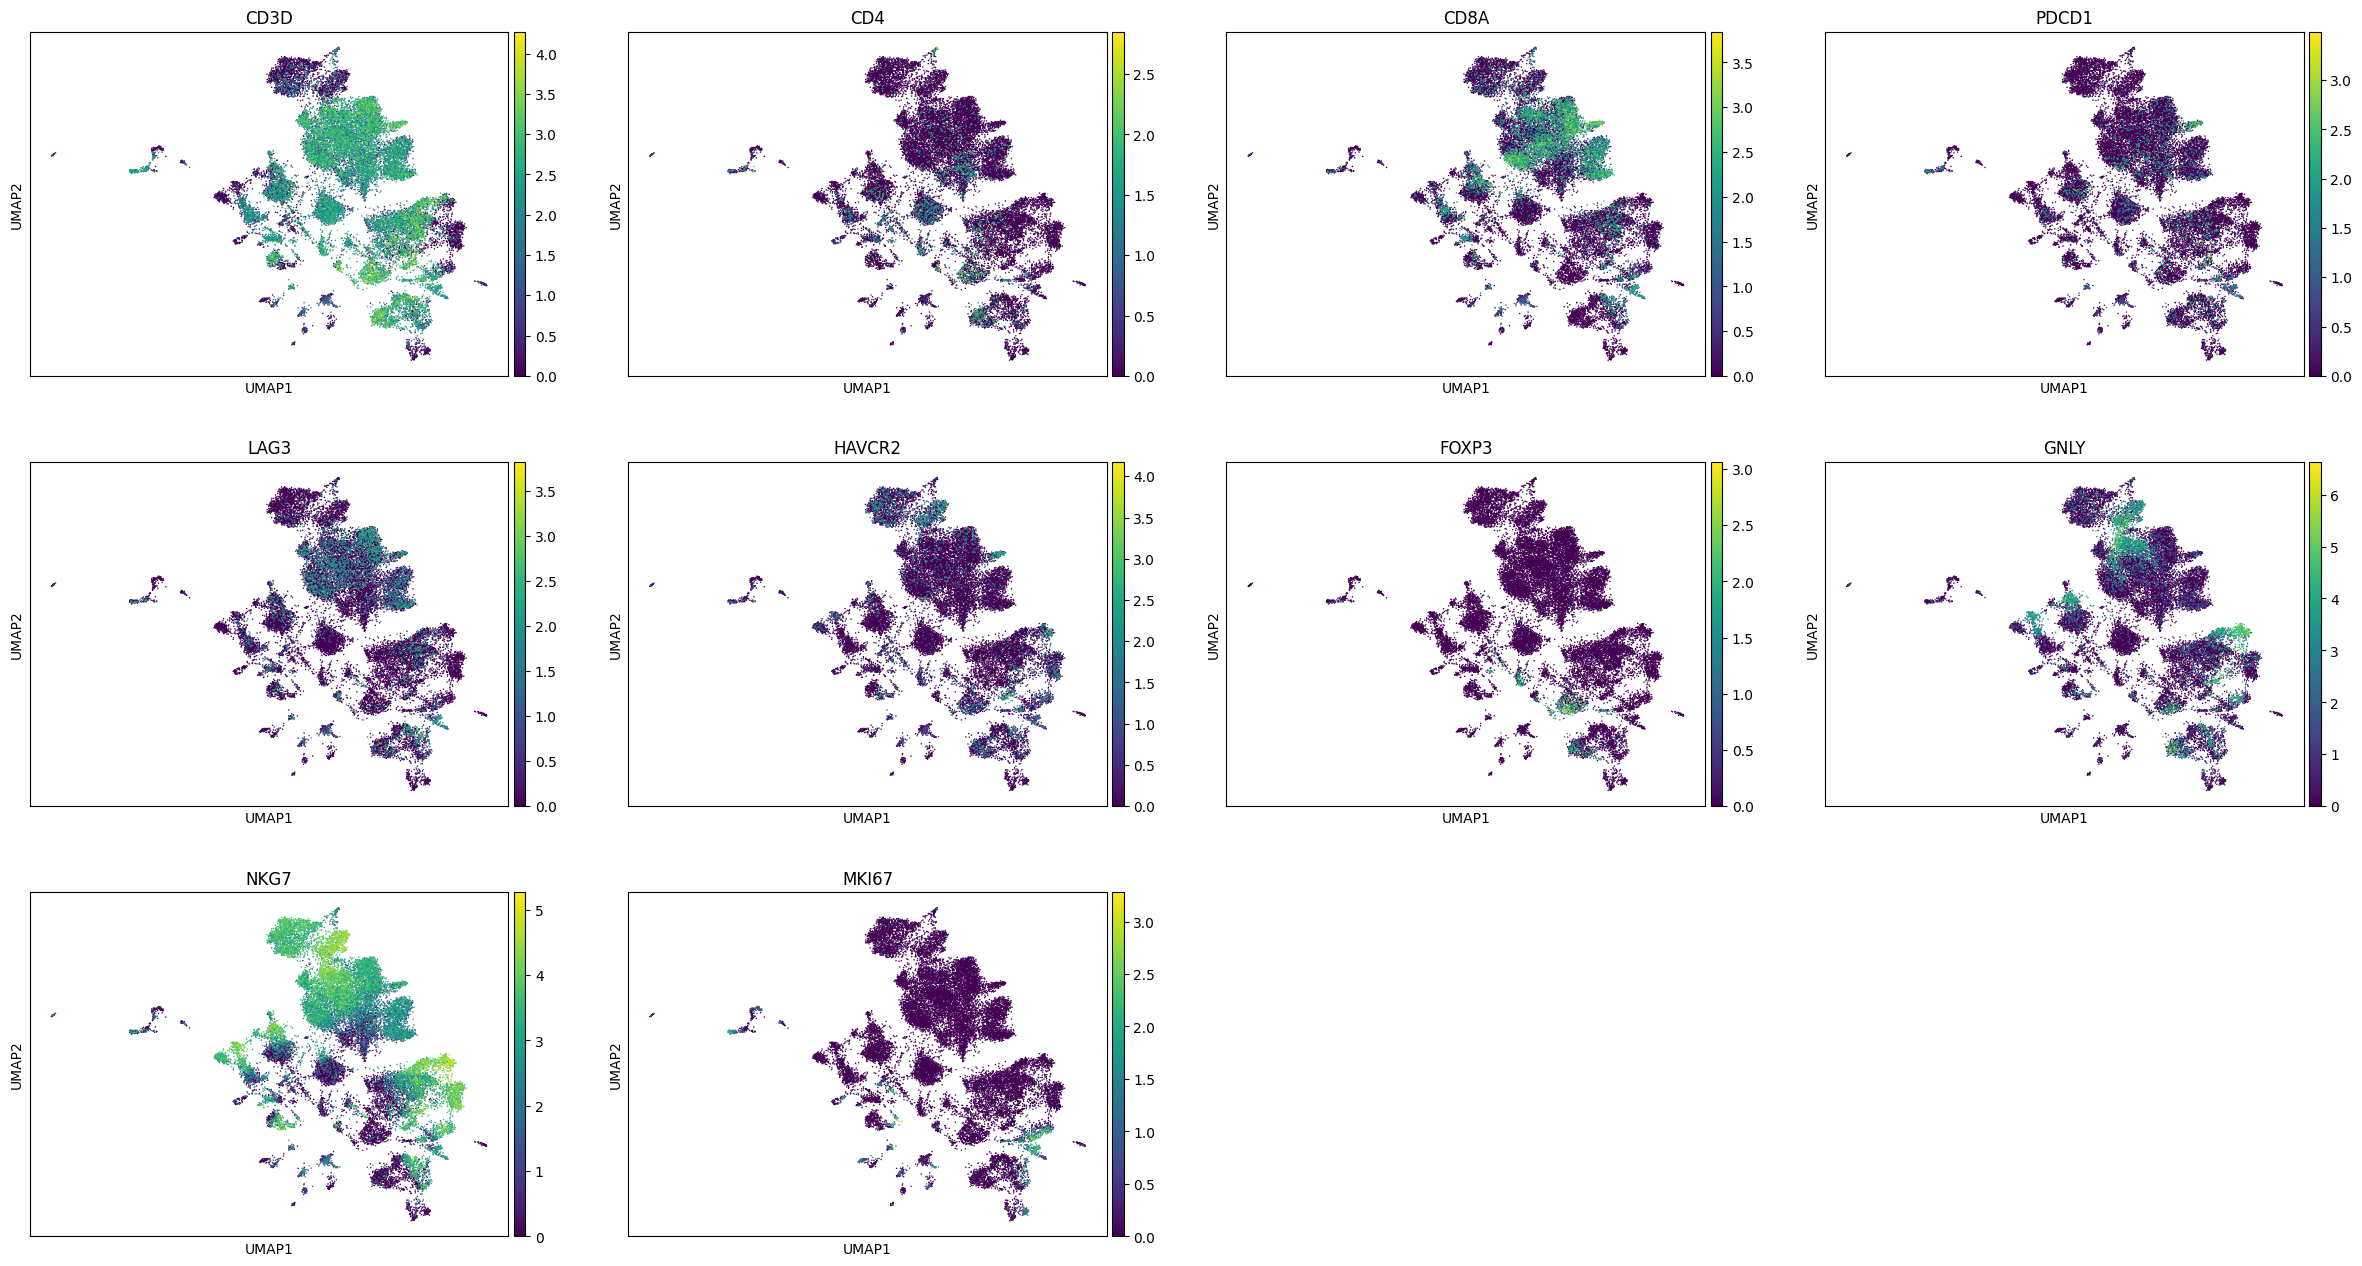

In [14]:
marker_genes = [
    "CD3D", "CD4", "CD8A",
    "PDCD1", "LAG3", "HAVCR2",  # exhaustion
    "FOXP3",                     # Treg
    "GNLY", "NKG7",              # cytotoxic
    "MKI67"                      # proliferation
]

sc.pl.umap(adata_t, color=marker_genes)

In [15]:
adata_m = adata_log[adata_log.obs["celltype"] == "Myeloid"].copy()

sc.pp.highly_variable_genes(adata_m, n_top_genes=2000)
adata_m = adata_m[:, adata_m.var.highly_variable].copy()

sc.pp.scale(adata_m, max_value=10)

# Guard against non-finite values before PCA
if sparse.issparse(adata_m.X):
    adata_m.X.data = np.nan_to_num(adata_m.X.data, nan=0.0, posinf=0.0, neginf=0.0)
else:
    adata_m.X = np.nan_to_num(adata_m.X, nan=0.0, posinf=0.0, neginf=0.0)

sc.tl.pca(adata_m)
sc.pp.neighbors(adata_m)
sc.tl.umap(adata_m)
sc.tl.leiden(adata_m, resolution=0.8)



/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/functools.py:982: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
/var/folders/d3/flzyycm51ddb3vbl4r5q6m740000gn/T/ipykernel_87175/1668022502.py:17: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata_m, resolution=0.8)


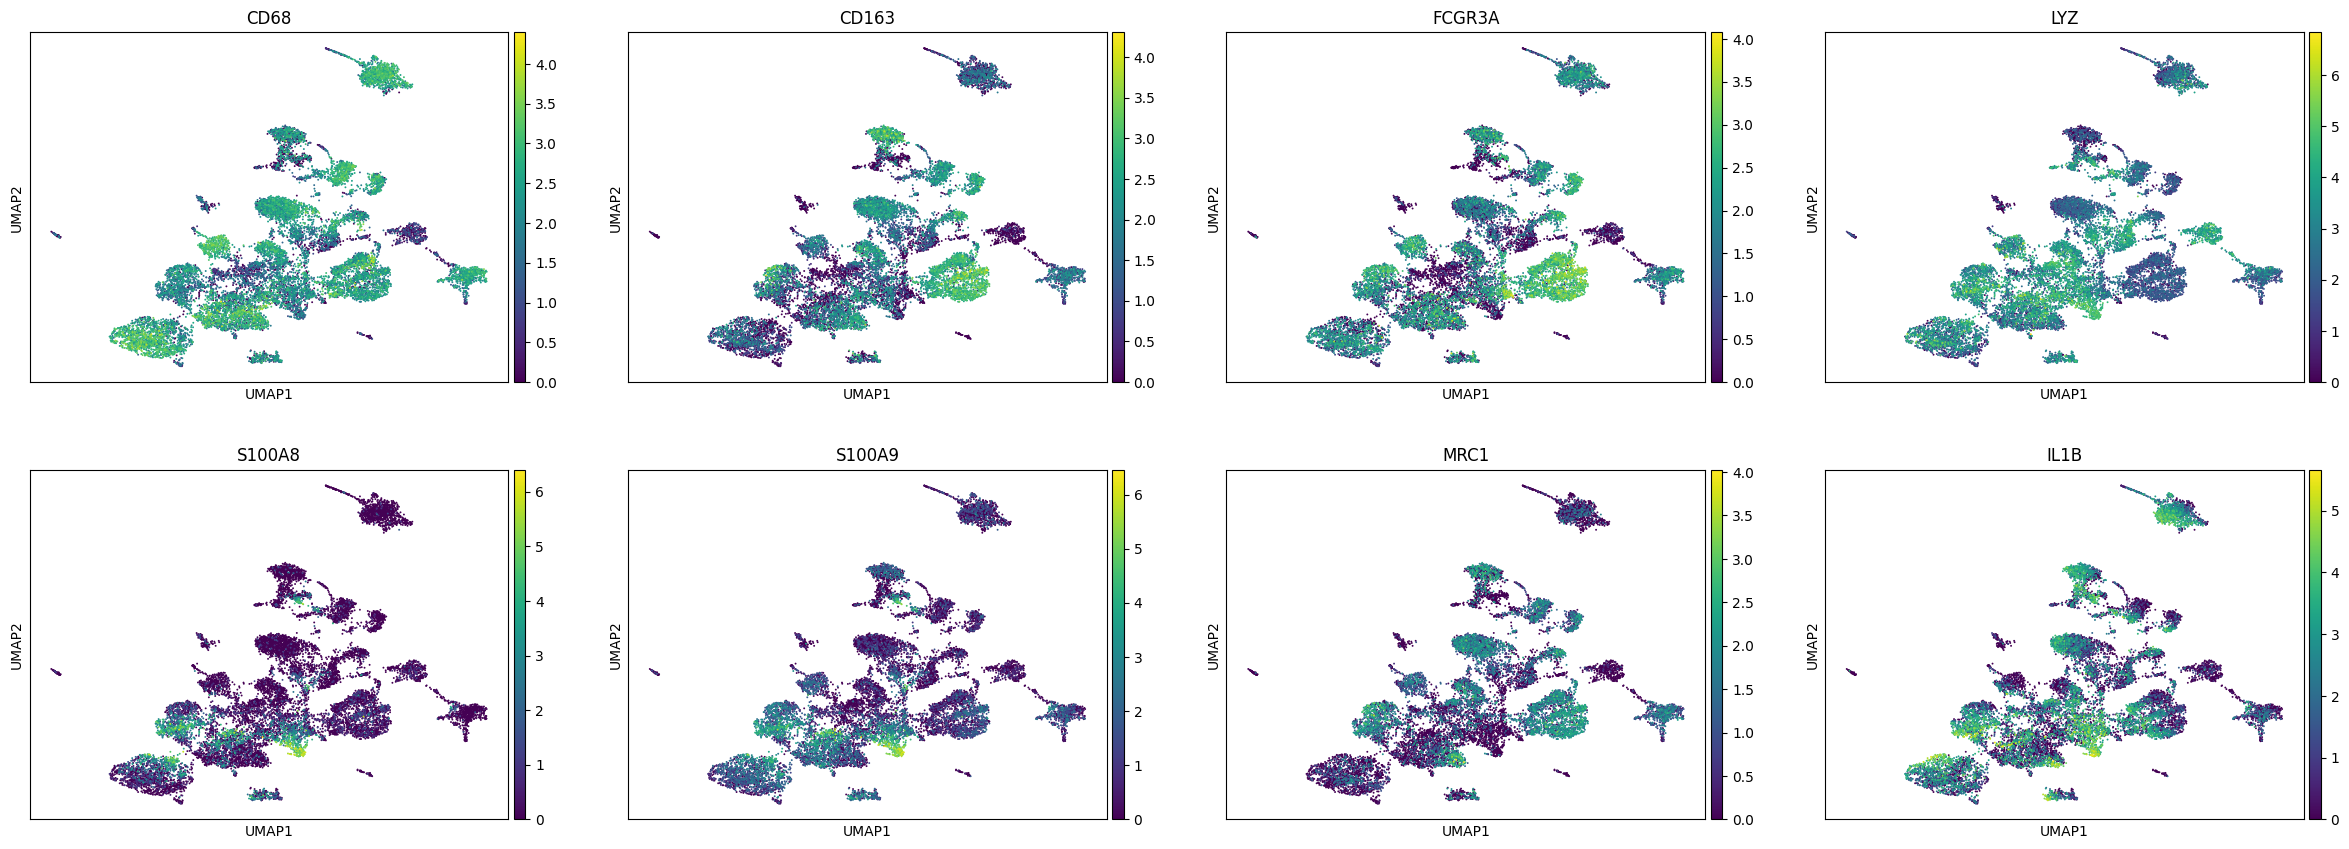

In [16]:
import numpy as np
from scipy import sparse

markers_myeloid = [
    "CD68", "CD163",  # TAM M2-like
    "FCGR3A",         # inflammatory mono
    "LYZ",            # monocytes
    "S100A8", "S100A9",  # neutrophil-like
    "MRC1",           # M2
    "IL1B"            # inflammatory
]

# Recover if kernel was restarted or execution order skipped
if "adata_m" not in globals():
    source_adata = adata_log if "adata_log" in globals() else adata
    adata_m = source_adata[source_adata.obs["celltype"] == "Myeloid"].copy()
    sc.pp.highly_variable_genes(adata_m, n_top_genes=2000)
    adata_m = adata_m[:, adata_m.var.highly_variable].copy()
    sc.pp.scale(adata_m, max_value=10)
    if sparse.issparse(adata_m.X):
        adata_m.X.data = np.nan_to_num(adata_m.X.data, nan=0.0, posinf=0.0, neginf=0.0)
    else:
        adata_m.X = np.nan_to_num(adata_m.X, nan=0.0, posinf=0.0, neginf=0.0)

if "X_umap" not in adata_m.obsm:
    if "X_pca" not in adata_m.obsm:
        sc.tl.pca(adata_m)
    if "neighbors" not in adata_m.uns:
        sc.pp.neighbors(adata_m)
    sc.tl.umap(adata_m)

sc.pl.umap(adata_m, color=markers_myeloid)



In [17]:
exhaustion_genes = [
    "PDCD1",  # PD-1
    "LAG3",
    "HAVCR2", # TIM3
    "TIGIT",
    "CTLA4"
]

sc.tl.score_genes(adata_t, exhaustion_genes, score_name="exhaustion_score")

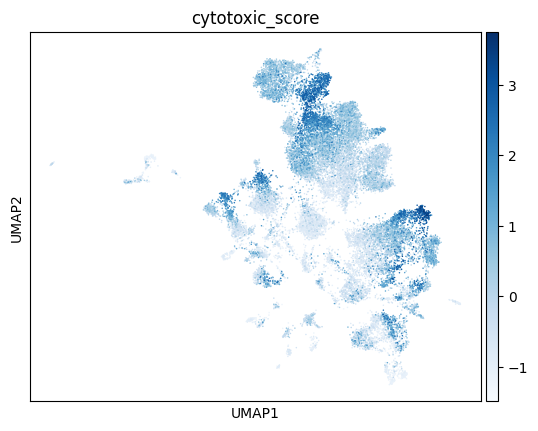

In [18]:
cytotoxic_genes = [
    "GZMB",
    "PRF1",
    "GNLY",
    "NKG7"
]

sc.tl.score_genes(adata_t, cytotoxic_genes, score_name="cytotoxic_score")
sc.pl.umap(adata_t, color="cytotoxic_score", cmap="Blues")

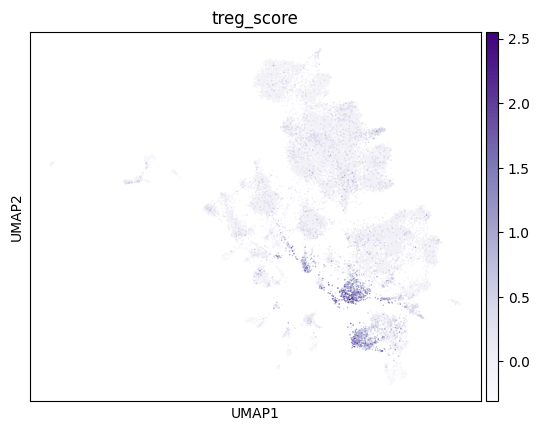

In [19]:
treg_genes = [
    "FOXP3",
    "IL2RA",
    "CTLA4",
    "IKZF2"
]

sc.tl.score_genes(adata_t, treg_genes, score_name="treg_score")
sc.pl.umap(adata_t, color="treg_score", cmap="Purples")

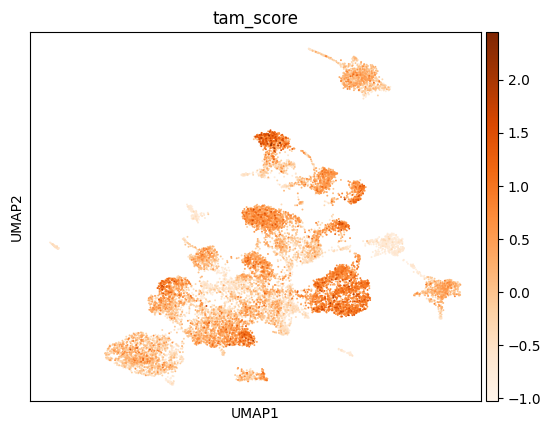

In [20]:
tam_genes = [
    "CD163",
    "MRC1",
    "MSR1",
    "IL10"
]

sc.tl.score_genes(adata_m, tam_genes, score_name="tam_score")
sc.pl.umap(adata_m, color="tam_score", cmap="Oranges")

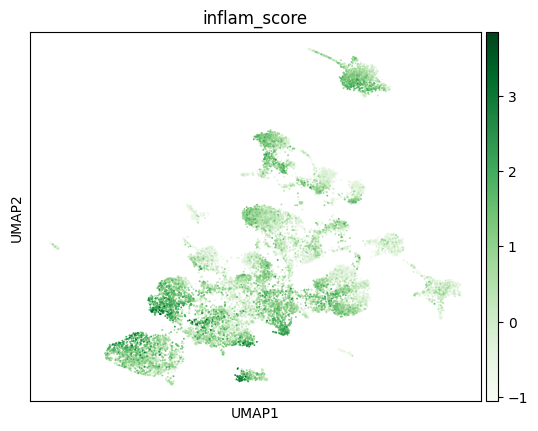

In [21]:
inflam_genes = [
    "IL1B",
    "TNF",
    "CXCL8",
    "CCL2"
]

sc.tl.score_genes(adata_m, inflam_genes, score_name="inflam_score")
sc.pl.umap(adata_m, color="inflam_score", cmap="Greens")

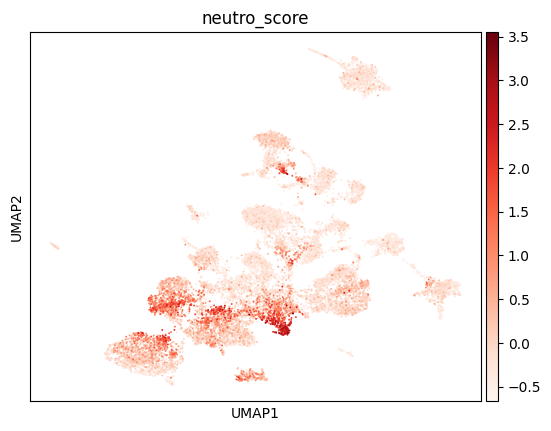

In [22]:
neutro_genes = [
    "S100A8",
    "S100A9",
    "FCGR3B",
    "CSF3R"
]

sc.tl.score_genes(adata_m, neutro_genes, score_name="neutro_score")
sc.pl.umap(adata_m, color="neutro_score", cmap="Reds")

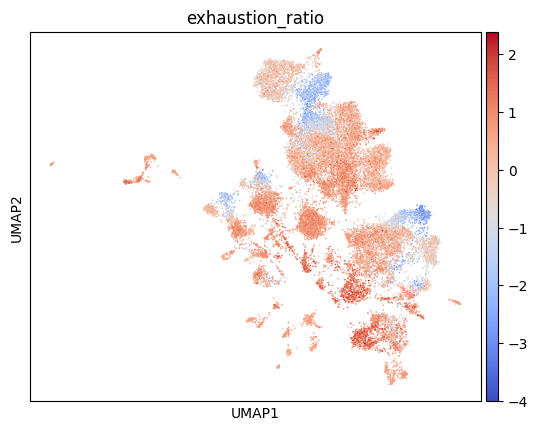

In [23]:
adata_t.obs["exhaustion_ratio"] = (
    adata_t.obs["exhaustion_score"] -
    adata_t.obs["cytotoxic_score"]
)

sc.pl.umap(adata_t, color="exhaustion_ratio", cmap="coolwarm")

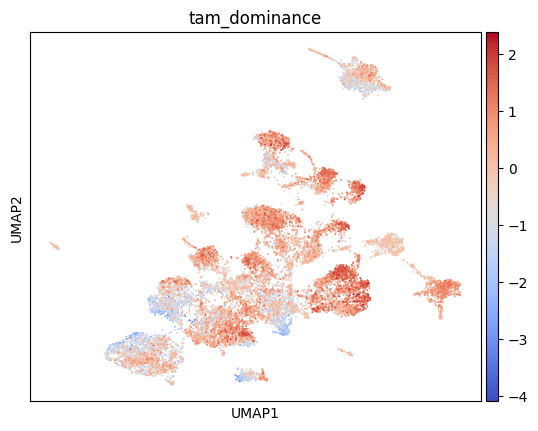

In [24]:
adata_m.obs["tam_dominance"] = (
    adata_m.obs["tam_score"] -
    adata_m.obs["inflam_score"]
)

sc.pl.umap(adata_m, color="tam_dominance", cmap="coolwarm")

In [25]:
t_cluster = adata_t.obs.groupby("leiden")[["exhaustion_score", "cytotoxic_score"]].mean()
print(t_cluster)

        exhaustion_score  cytotoxic_score
leiden                                   
0              -0.008212         0.101402
1              -0.085464         0.114104
2              -0.115460         0.699438
3              -0.161449         0.336920
4              -0.173955         1.716832
5              -0.224968        -0.208628
6              -0.226572        -0.733393
7               0.121082        -0.272420
8              -0.117904        -0.219622
9              -0.292556        -0.892362
10             -0.187933        -0.187020
11             -0.127771         0.049503
12             -0.275476         0.047701
13              0.289134        -0.601190
14             -0.141744         0.558397
15              0.030255         0.084404
16             -0.264566        -0.503441
17             -0.131786        -0.001566
18             -0.258428        -0.873338
19             -0.505403        -1.016189
20              0.196540        -0.814468
21             -0.073706        -0

/var/folders/d3/flzyycm51ddb3vbl4r5q6m740000gn/T/ipykernel_87175/2325422520.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  t_cluster = adata_t.obs.groupby("leiden")[["exhaustion_score", "cytotoxic_score"]].mean()


In [26]:
m_cluster = adata_m.obs.groupby("leiden")[["tam_score", "inflam_score"]].mean()
print(m_cluster)

        tam_score  inflam_score
leiden                         
0        0.023407      0.197263
1        0.592897      0.099019
2       -0.219257      0.597862
3        0.278834      0.109088
4        0.179183      0.395285
5       -0.112385      0.598441
6        0.047740      1.100569
7       -0.414868      0.586624
8       -0.429126      0.140060
9       -0.049578     -0.136408
10      -0.076136     -0.389839
11       0.132193     -0.185266
12       0.119603      0.116190
13      -0.065323     -0.249116
14      -0.755252     -0.478453
15      -0.272350     -0.139548
16       0.452844     -0.207115
17      -0.111927      0.905358
18      -0.174469      0.282626
19      -0.731602     -0.601884
20      -0.402464      0.023877
21      -0.654626     -0.436610
22      -0.601020     -0.484314
23      -0.784320     -0.728119
24      -0.210595     -0.001430


/var/folders/d3/flzyycm51ddb3vbl4r5q6m740000gn/T/ipykernel_87175/1876124689.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  m_cluster = adata_m.obs.groupby("leiden")[["tam_score", "inflam_score"]].mean()


In [27]:
t_patient = adata_t.obs.groupby("sample")[["exhaustion_score","cytotoxic_score"]].mean()
m_patient = adata_m.obs.groupby("sample")[["tam_score"]].mean()

combined = t_patient.join(m_patient)
print(combined.corr())

                  exhaustion_score  cytotoxic_score  tam_score
exhaustion_score          1.000000         0.229403  -0.149316
cytotoxic_score           0.229403         1.000000   0.270306
tam_score                -0.149316         0.270306   1.000000


/var/folders/d3/flzyycm51ddb3vbl4r5q6m740000gn/T/ipykernel_87175/3016888005.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  t_patient = adata_t.obs.groupby("sample")[["exhaustion_score","cytotoxic_score"]].mean()
/var/folders/d3/flzyycm51ddb3vbl4r5q6m740000gn/T/ipykernel_87175/3016888005.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  m_patient = adata_m.obs.groupby("sample")[["tam_score"]].mean()


In [28]:
adata_m.obs["tam_dominance"] = (
    adata_m.obs["tam_score"] - adata_m.obs["inflam_score"]
)

m_patient = adata_m.obs.groupby("sample")[["tam_dominance"]].mean()

combined = t_patient.join(m_patient)
print(combined.corr())

                  exhaustion_score  cytotoxic_score  tam_dominance
exhaustion_score          1.000000         0.229403      -0.334918
cytotoxic_score           0.229403         1.000000       0.231966
tam_dominance            -0.334918         0.231966       1.000000


/var/folders/d3/flzyycm51ddb3vbl4r5q6m740000gn/T/ipykernel_87175/1657462864.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  m_patient = adata_m.obs.groupby("sample")[["tam_dominance"]].mean()


In [29]:
# T cell fraction per sample
t_fraction = (
    adata.obs[adata.obs["celltype"] == "T/NK"]
    .groupby("sample")
    .size()
    / adata.obs.groupby("sample").size()
)

# TAM dominance per sample (already computed)
combined2 = pd.concat([t_fraction, m_patient["tam_dominance"]], axis=1)
combined2.columns = ["t_fraction", "tam_dominance"]

print(combined2.corr())

               t_fraction  tam_dominance
t_fraction       1.000000       0.207317
tam_dominance    0.207317       1.000000


/var/folders/d3/flzyycm51ddb3vbl4r5q6m740000gn/T/ipykernel_87175/341134335.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("sample")
/var/folders/d3/flzyycm51ddb3vbl4r5q6m740000gn/T/ipykernel_87175/341134335.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  / adata.obs.groupby("sample").size()


In [30]:
combined3 = pd.concat([t_fraction, t_patient["exhaustion_score"]], axis=1)
combined3.columns = ["t_fraction", "exhaustion_score"]
print(combined3.corr())

                  t_fraction  exhaustion_score
t_fraction          1.000000         -0.035336
exhaustion_score   -0.035336          1.000000


In [31]:
# Optional: save compact outputs for reuse
adata.write("adata_scRNA_processed.h5ad")
adata_t.write("adata_t_processed.h5ad")
adata_m.write("adata_m_processed.h5ad")
print("Saved: adata_scRNA_processed.h5ad, adata_t_processed.h5ad, adata_m_processed.h5ad")


Saved: adata_scRNA_processed.h5ad, adata_t_processed.h5ad, adata_m_processed.h5ad
